# Complex Numbers — Lecture 4
## Argument of a Complex Number · Principal vs General Argument · Quadrant Rules · Properties of arg

**Source:** [Complex Numbers 04 | Argument of a Complex Number | Class 11 | JEE](https://www.youtube.com/watch?v=Fg9Kh7t55T0&list=PLF_7kfnwLFCFWA-D3XAPqcyB1z68dbgUg&index=4), Physics Wallah (Class 11), about 51 min

**Prerequisite:** Lectures 1–3 (Argand plane, conjugate, modulus). Trigonometry: angles measured anticlockwise are positive, clockwise are negative, and $\theta$, $\theta + 2\pi$, $\theta - 2\pi$, … describe the same direction.

### What this lecture covers
1. **Definition** of $\arg z$: the angle the segment $Oz$ makes with the **positive real axis**
2. **General argument** vs **principal argument** (also called the **amplitude**, $\operatorname{amp} z$), with $-\pi < \operatorname{Arg} z \le \pi$
3. Worked examples in **every quadrant**: $1 + i$, $-1 + \sqrt3 i$, $-\sqrt3 - i$, $1 - i$
4. Numbers **on the axes**: $5$, $-6$, $9i$, $-9i$
5. Summary rules, and why **$\arg 0$ is not defined**
6. **Properties:** $\arg(z_1z_2)$, $\arg(z_1/z_2)$, $\arg(z^n)$, $\arg\bar z$, and the one exception
7. Homework: $\arg\big[(1 + i)(\sqrt3 + i)\big]$ and $\arg\big[(1 - i)^3\big]$

> The lecturer's opening line: *we stumble on pebbles, not on mountains.* Small mistakes in arg, like the wrong sign or the wrong range, cost the most marks, so this lecture goes slowly through the details.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–3
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(4)
PI_TICKS = (np.arange(-4, 5)*np.pi/4, ["−π", "−3π/4", "−π/2", "−π/4", "0", "π/4", "π/2", "3π/4", "π"])

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14, shrinkA=0, shrinkB=0))

def angle_arc(ax, theta, r=0.5, color=ORANGE, lw=2, start=0.0):
    # Arc from angle `start` to `theta`, with an arrowhead showing the direction (anticlockwise if theta > start)
    t = np.linspace(start, theta, 80)
    ax.plot(r*np.cos(t), r*np.sin(t), color=color, lw=lw)
    ax.annotate("", (r*np.cos(t[-1]), r*np.sin(t[-1])), (r*np.cos(t[-6]), r*np.sin(t[-6])),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12))

def pi_str(x):
    # Pretty-print a multiple of π/12 like "5π/6" or "−π/4"
    from fractions import Fraction
    f = Fraction(x/np.pi).limit_denominator(12)
    if f == 0: return "0"
    s = "−" if f < 0 else ""; f = abs(f)
    num = "" if f.numerator == 1 else str(f.numerator)
    return f"{s}{num}π" + ("" if f.denominator == 1 else f"/{f.denominator}")
print("ready")

ready


---
## 1. What Is the Argument?

Take $z = a + ib$ as a point $P$ in the Argand plane. **Join $P$ to the origin $O$.** The angle that the segment $OP$ makes with the **positive direction of the real axis** is called the **argument** of $z$:
$$\arg z = \theta$$

- Measured **anticlockwise** from the positive real axis gives a **positive** angle.
- Measured **clockwise** gives a **negative** angle (as in trigonometry).
- Arguments are given in **radians**.

So $|z|$ (Lecture 2) tells you **how far** $z$ is from $O$, and $\arg z$ tells you **in which direction**. Together they pin down the point, which is why this lecture is where "a complex number tells you the address" becomes complete.

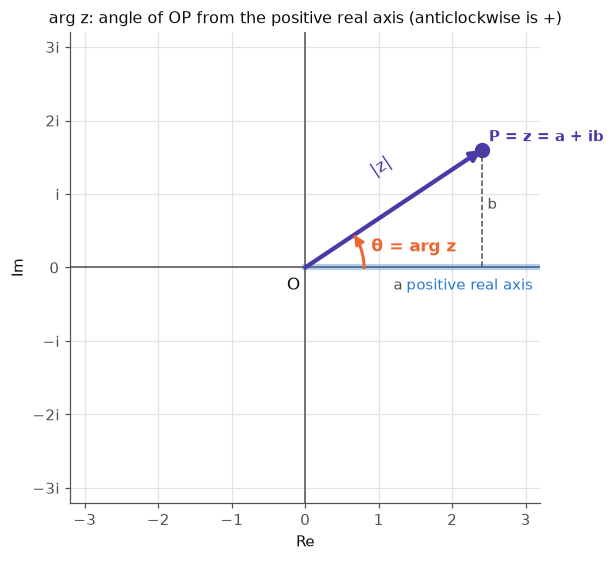

In [2]:
z = 2.4 + 1.6j
fig, ax = plt.subplots(figsize=(6.4, 5.2)); argand(ax, lim=3.2)
ax.axhline(0, xmin=0.5, color=BLUE, lw=4, alpha=0.35)
ax.text(3.1, -0.3, "positive real axis", color=BLUE, ha="right", fontsize=9.5)
arrow(ax, 0, z, VIOLET, 2.8)
ax.plot(z.real, z.imag, "o", color=VIOLET, ms=9)
ax.text(z.real + 0.1, z.imag + 0.12, "P = z = a + ib", color=VIOLET, weight="bold")
ax.plot([z.real, z.real], [0, z.imag], color=INK2, ls="--", lw=1)
ax.text(z.real + 0.08, z.imag/2, "b", color=INK2); ax.text(z.real/2, -0.3, "a", color=INK2)
angle_arc(ax, np.angle(z), r=0.8)
ax.text(0.9, 0.22, "θ = arg z", color=ORANGE, fontsize=11, weight="bold")
ax.text(0.85, 1.25, "|z|", color=VIOLET, fontsize=11, rotation=np.degrees(np.angle(z)))
ax.text(-0.25, -0.3, "O", fontsize=11)
ax.set_title("arg z: angle of OP from the positive real axis (anticlockwise is +)", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 2. General Argument and Principal Argument

The same direction can be described by many angles. $\frac{\pi}{4}$, $\frac{\pi}{4} + 2\pi$, $\frac{\pi}{4} + 4\pi$, $\frac{\pi}{4} - 2\pi$, … all point the same way. So there are two kinds of argument:

**Principal argument** (also called the **amplitude**, written $\operatorname{Arg} z$ or $\operatorname{amp} z$): the unique value with
$$\boxed{-\pi < \operatorname{Arg} z \le \pi}$$
Note the **strict** "$<$" on the left and "$\le$" on the right. $\pi$ is allowed and $-\pi$ is not.

**General argument:** all of them, written in one formula by adding whole turns to the principal value:
$$\boxed{\arg z = \operatorname{Arg} z + 2k\pi, \qquad k \in \mathbb{Z}}$$

> **Default rule:** whenever a question says just "argument" without specifying, it means the **principal** argument. Find the principal value first. The general value is then just "$+\,2k\pi$".

### Example: $z = 1 + i$
The point is $(1, 1)$. In the right triangle with base $1$ and height $1$: $\tan\theta = \frac11 = 1$, so $\theta = \frac{\pi}{4}$.
$$\operatorname{Arg}(1 + i) = \frac{\pi}{4}, \qquad \arg(1 + i) = \frac{\pi}{4} + 2k\pi$$

In [3]:
z = 1 + 1j
print("principal Arg(1 + i) =", pi_str(np.angle(z)), " (numpy's np.angle returns the principal value)")
print("general values π/4 + 2kπ:", ", ".join(pi_str(np.angle(z) + 2*k*np.pi) for k in range(-2, 3)))
# Check that they all point the same way
print("same direction?", np.allclose([np.exp(1j*(np.pi/4 + 2*k*np.pi)) for k in range(-2, 3)], z/abs(z)))

principal Arg(1 + i) = π/4  (numpy's np.angle returns the principal value)
general values π/4 + 2kπ: −15π/4, −7π/4, π/4, 9π/4, 17π/4
same direction? True


### Animation *(extra)*: the principal argument jumps at the negative real axis
A point travels once around a circle, anticlockwise, starting just below the negative real axis. On the right:
- the **general** argument, which keeps growing smoothly ($\theta$, then $\theta + 2\pi$, …),
- the **principal** argument, which must stay in $(-\pi, \pi]$. It climbs to $+\pi$ on the negative real axis, then **jumps to just above $-\pi$** the moment the point crosses into the third quadrant.

That jump is why third- and fourth-quadrant numbers get **negative** principal arguments.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.35]))
ax = axes[0]; argand(ax, lim=1.6)
th = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(th), np.sin(th), color=GRID, lw=1.5)
ax.plot([-1.6, 0], [0, 0], color=ORANGE, lw=4, alpha=0.4); ax.text(-1.55, 0.1, "Arg = π here", color=ORANGE, fontsize=9)
seg, = ax.plot([], [], color=VIOLET, lw=2.5); dot, = ax.plot([], [], "o", color=VIOLET, ms=9)
arc, = ax.plot([], [], color=ORANGE, lw=2)
lab = ax.text(-1.5, -1.45, "", fontsize=10, family="monospace")
ax.set_title("z moves anticlockwise", fontsize=10.5)

ax2 = axes[1]
start = -np.pi + 0.15
travel = np.linspace(0, 2*np.pi, 400); gen = start + travel; pri = np.angle(np.exp(1j*gen))
ax2.plot(travel, gen, color=BLUE, lw=1, alpha=0.25); ax2.plot(travel, np.where(np.abs(np.diff(pri, prepend=pri[0])) > 1, np.nan, pri), color=VIOLET, lw=1, alpha=0.25)
ax2.axhspan(-np.pi, np.pi, color=VIOLET, alpha=0.05)
ax2.axhline(np.pi, color=INK2, lw=0.8, ls="--"); ax2.axhline(-np.pi, color=INK2, lw=0.8, ls="--")
g_line, = ax2.plot([], [], color=BLUE, lw=2.5, label="general arg (smooth)")
p_line, = ax2.plot([], [], color=VIOLET, lw=2.5, label="principal Arg ∈ (−π, π]")
gd, = ax2.plot([], [], "o", color=BLUE, ms=7); pd, = ax2.plot([], [], "o", color=VIOLET, ms=7)
ax2.set_yticks(*PI_TICKS); ax2.set_ylim(-3.5, 4.2)
ax2.set_xticks(np.arange(0, 5)*np.pi/2, ["0", "π/2", "π", "3π/2", "2π"]); ax2.set_xlabel("angle travelled")
ax2.legend(frameon=False, fontsize=9, loc="upper left"); ax2.set_title("principal value wraps, general value doesn't", fontsize=10.5)
N = 56
def update(f):
    k = int(f/(N - 1)*(len(travel) - 1)); g = gen[k]; z = np.exp(1j*g); p = np.angle(z)
    seg.set_data([0, z.real], [0, z.imag]); dot.set_data([z.real], [z.imag])
    t = np.linspace(0, p, 60); arc.set_data(0.45*np.cos(t), 0.45*np.sin(t))
    lab.set_text(f"Arg z = {p:+.2f}  ({np.degrees(p):+.0f}°)")
    g_line.set_data(travel[:k + 1], gen[:k + 1]); gd.set_data([travel[k]], [g])
    pp = pri[:k + 1].copy(); pp[1:][np.abs(np.diff(pp)) > 1] = np.nan
    p_line.set_data(travel[:k + 1], pp); pd.set_data([travel[k]], [p])
    return seg, dot, arc, lab, g_line, p_line, gd, pd
anim = animation.FuncAnimation(fig, update, frames=N, interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## 3. Finding the Principal Argument in Each Quadrant

**Method (the lecturer insists on step 1):**
1. **Plot the point** and see which quadrant it is in. Skipping this is where mistakes happen.
2. Find the **acute angle** $\alpha$ between $Oz$ and the real axis: $\tan\alpha = \left|\dfrac{b}{a}\right|$.
3. Measure from the positive real axis **in whichever direction keeps the answer in $(-\pi, \pi]$**. Go anticlockwise (positive) for the upper half and clockwise (negative) for the lower half.

| Quadrant | Example | Acute angle $\alpha$ | $\operatorname{Arg} z$ | Rule |
|---|---|---|---|---|
| I | $1 + i$ | $\tan\alpha = 1$, so $\frac{\pi}{4}$ | $\frac{\pi}{4}$ | $\alpha$ |
| II | $-1 + \sqrt3\,i$ | $\tan\alpha = \sqrt3$, so $\frac{\pi}{3}$ | $\pi - \frac{\pi}{3} = \frac{2\pi}{3}$ | $\pi - \alpha$ |
| III | $-\sqrt3 - i$ | $\tan\alpha = \frac{1}{\sqrt3}$, so $\frac{\pi}{6}$ | $-\left(\pi - \frac{\pi}{6}\right) = -\frac{5\pi}{6}$ | $-(\pi - \alpha)$ |
| IV | $1 - i$ | $\tan\alpha = 1$, so $\frac{\pi}{4}$ | $-\frac{\pi}{4}$ | $-\alpha$ |

**Why III is negative:** going anticlockwise to $-\sqrt3 - i$ would take you past $\pi$ (to $\frac{7\pi}{6}$), which is **outside** the principal range. So you must go **clockwise**, and a clockwise angle is negative: $-\frac{5\pi}{6}$.

General values: add $2k\pi$. For example, $\arg(-\sqrt3 - i) = -\frac{5\pi}{6} + 2k\pi$.

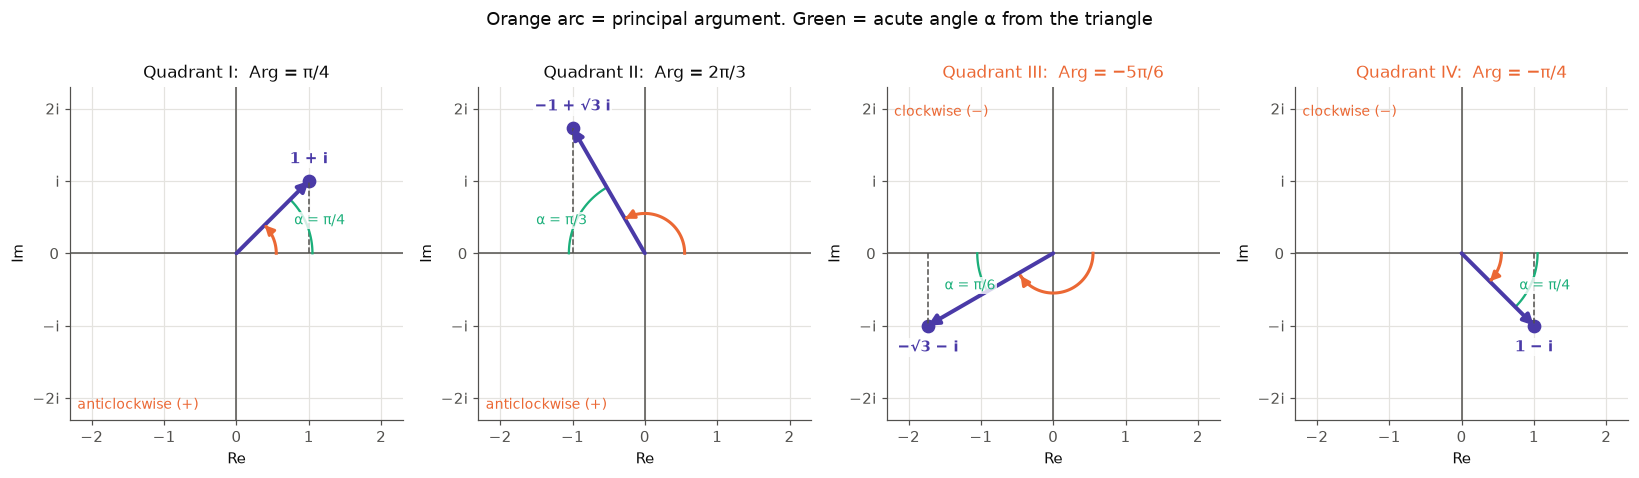

Quadrant   I: Arg(1 + i) =    π/4   general: π/4 + 2kπ
Quadrant  II: Arg(−1 + √3 i) =   2π/3   general: 2π/3 + 2kπ
Quadrant III: Arg(−√3 − i) =  −5π/6   general: −5π/6 + 2kπ
Quadrant  IV: Arg(1 − i) =   −π/4   general: −π/4 + 2kπ


In [5]:
examples = [("I", 1 + 1j, "1 + i"), ("II", -1 + np.sqrt(3)*1j, "−1 + √3 i"), ("III", -np.sqrt(3) - 1j, "−√3 − i"), ("IV", 1 - 1j, "1 − i")]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.3))
for ax, (q, z, name) in zip(axes, examples):
    argand(ax, lim=2.3)
    p = np.angle(z); a = np.arctan(abs(z.imag/z.real))
    arrow(ax, 0, z, VIOLET, 2.6); ax.plot(z.real, z.imag, "o", color=VIOLET, ms=8)
    ax.plot([z.real, z.real], [0, z.imag], color=INK2, ls="--", lw=1)
    angle_arc(ax, p, r=0.55, color=ORANGE)
    # Mark the acute angle α at the origin, measured from the nearer side of the real axis
    base = 0 if z.real > 0 else np.pi
    t = np.linspace(base, base + np.sign(z.imag)*a*(1 if z.real > 0 else -1), 40)
    ax.plot(1.05*np.cos(t), 1.05*np.sin(t), color=AQUA, lw=1.5)
    ax.text(1.15*np.sign(z.real), 0.45*np.sign(z.imag), f"α = {pi_str(a)}", color=AQUA, fontsize=9, ha="center", va="center",
            bbox=dict(fc="white", ec="none", alpha=0.8, pad=1))
    ax.text(z.real, z.imag + 0.3*np.sign(z.imag), name, color=VIOLET, weight="bold", ha="center", va="center", fontsize=10,
            bbox=dict(fc="white", ec="none", alpha=0.8, pad=1))
    ax.set_title(f"Quadrant {q}:  Arg = {pi_str(p)}", fontsize=11, color=ORANGE if p < 0 else INK)
    ax.text(-2.2, -2.15 if z.imag > 0 else 1.9, "anticlockwise (+)" if p > 0 else "clockwise (−)", fontsize=9, color=ORANGE)
fig.suptitle("Orange arc = principal argument. Green = acute angle α from the triangle", fontsize=11.5)
plt.tight_layout(); plt.show()
for q, z, name in examples:
    print(f"Quadrant {q:>3}: Arg({name}) = {pi_str(np.angle(z)):>6}   general: {pi_str(np.angle(z))} + 2kπ")

---
## 4. Numbers on the Axes

| $z$ | Where | $\operatorname{Arg} z$ |
|---|---|---|
| $5$ | positive real axis | $0$ |
| $-6$ | negative real axis | $\pi$ (**not** $-\pi$, which is outside $(-\pi, \pi]$) |
| $9i$ | positive imaginary axis | $\frac{\pi}{2}$ |
| $-9i$ | negative imaginary axis | $-\frac{\pi}{2}$ |

For $-6$ you could measure either $\pi$ anticlockwise or $-\pi$ clockwise. The range $-\pi < \theta \le \pi$ includes $\pi$ but not $-\pi$, so the answer is $\pi$.

### Why $\arg 0$ is not defined
An angle is formed between **two lines**. For $z = 0$, "joining $z$ to the origin" gives a single **point**, not a line. The angle between a point and a line isn't defined, so **$0$ is the only complex number with no argument**.

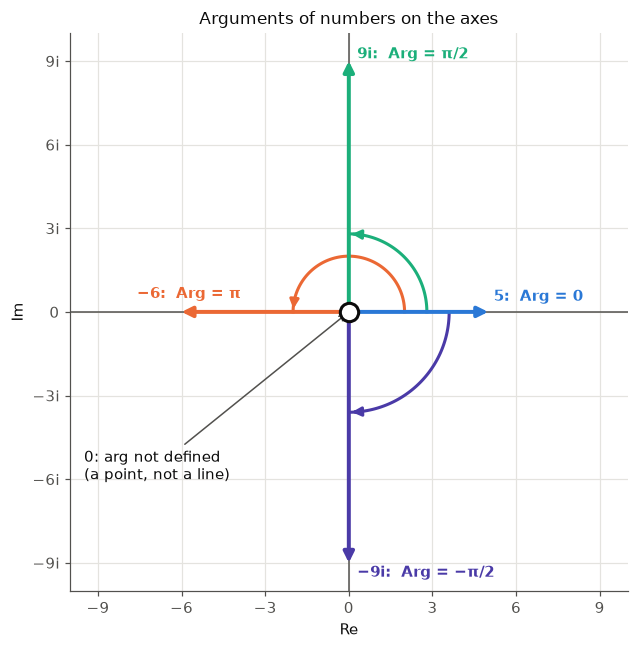

np.angle(  5) = 0
np.angle( −6) = π
np.angle( 9i) = π/2
np.angle(−9i) = −π/2

Pitfall (extra): numpy keeps a signed zero, so np.angle(complex(-6, -0.0)) = −π even though the textbook answer is π


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 6)); argand(ax, lim=10, ticks=3)
for z, name, c, p in [(5, "5", BLUE, 0), (-6, "−6", ORANGE, np.pi), (9j, "9i", AQUA, np.pi/2), (-9j, "−9i", VIOLET, -np.pi/2)]:
    z = complex(z); arrow(ax, 0, z, c, 2.6)
    if p != 0: angle_arc(ax, p, r={np.pi: 2.0, np.pi/2: 2.8, -np.pi/2: 3.6}[p], color=c)
    off = {"5": (0.2, 0.4), "−6": (-1.6, 0.5), "9i": (0.3, 0.1), "−9i": (0.3, -0.5)}[name]
    ax.text(z.real + off[0], z.imag + off[1], f"{name}:  Arg = {pi_str(p)}", color=c, weight="bold", fontsize=10)
ax.plot(0, 0, "o", ms=12, mfc="white", mec=INK, mew=2, zorder=6)
ax.annotate("0: arg not defined\n(a point, not a line)", (0, 0), xytext=(-9.5, -6), fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=INK2))
ax.set_title("Arguments of numbers on the axes", fontsize=11)
plt.tight_layout(); plt.show()

for z, name in [(5, "5"), (-6, "−6"), (9j, "9i"), (-9j, "−9i")]:
    print(f"np.angle({name:>3}) = {pi_str(np.angle(complex(z)))}")
print("\nPitfall (extra): numpy keeps a signed zero, so np.angle(complex(-6, -0.0)) =", pi_str(np.angle(complex(-6, -0.0))),
      "even though the textbook answer is π")

---
## 5. Highlights of the Argument

1. **Quadrants I and II** (upper half) have a **positive** principal argument, in $(0, \pi)$.
2. **Quadrants III and IV** (lower half) have a **negative** principal argument, in $(-\pi, 0)$.
3. Principal argument (amplitude): $-\pi < \operatorname{Arg} z \le \pi$. When the choice is between $-\pi$ and $\pi$, take $\pi$.
4. General argument $= \operatorname{Arg} z + 2k\pi$, with $k \in \mathbb{Z}$.
5. Axes: positive real gives $0$, negative real gives $\pi$, positive imaginary gives $\frac{\pi}{2}$, negative imaginary gives $-\frac{\pi}{2}$.
6. **$\arg 0$ is not defined.**

### Picture *(extra)*: the principal argument over the whole plane
Colour every point by its principal argument. Colours change smoothly everywhere **except across the negative real axis**, where $\operatorname{Arg}$ jumps from $+\pi$ (just above) to near $-\pi$ (just below). The upper half is all positive and the lower half all negative.

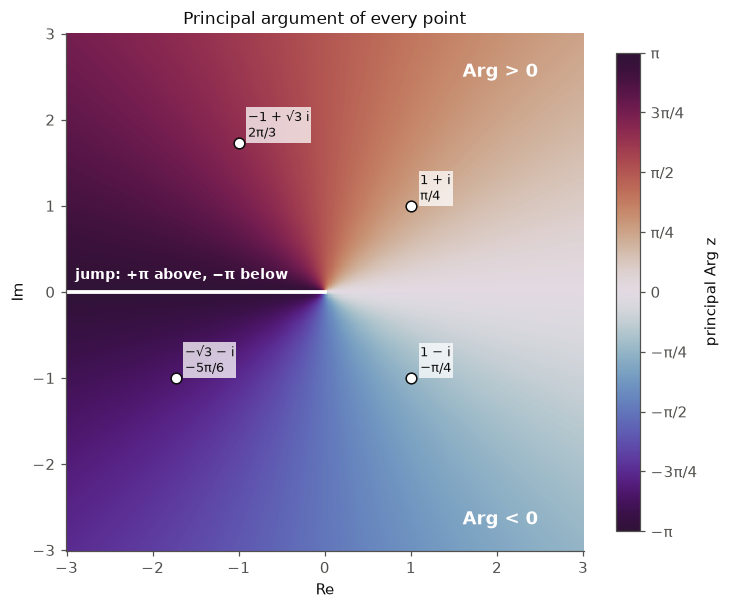

In [7]:
X, Y = np.meshgrid(np.linspace(-3, 3, 501), np.linspace(-3, 3, 501))
A = np.angle(X + 1j*Y)
fig, ax = plt.subplots(figsize=(6.8, 5.8)); ax.grid(False)
im = ax.pcolormesh(X, Y, A, cmap="twilight_shifted", shading="auto", vmin=-np.pi, vmax=np.pi)
ax.plot([-3, 0], [0, 0], color="white", lw=2.5); ax.text(-2.9, 0.15, "jump: +π above, −π below", color="white", fontsize=9, weight="bold")
for z, name in [(1 + 1j, "1 + i"), (-1 + np.sqrt(3)*1j, "−1 + √3 i"), (-np.sqrt(3) - 1j, "−√3 − i"), (1 - 1j, "1 − i")]:
    ax.plot(z.real, z.imag, "o", color="white", mec=INK, ms=7)
    ax.annotate(f"{name}\n{pi_str(np.angle(z))}", (z.real, z.imag), xytext=(6, 4), textcoords="offset points", fontsize=8.5, color=INK,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1))
ax.text(1.6, 2.5, "Arg > 0", fontsize=12, weight="bold", color="white"); ax.text(1.6, -2.7, "Arg < 0", fontsize=12, weight="bold", color="white")
ax.set_aspect("equal"); ax.set_xlabel("Re"); ax.set_ylabel("Im")
cb = fig.colorbar(im, ax=ax, shrink=0.85); cb.set_ticks(PI_TICKS[0], labels=PI_TICKS[1]); cb.set_label("principal Arg z")
ax.set_title("Principal argument of every point", fontsize=11)
plt.tight_layout(); plt.show()

---
## 6. Properties of the Argument

"arg" here means the **principal** argument unless stated otherwise. The $2k\pi$ in each property is there to **bring the answer back into $(-\pi, \pi]$** if the right side falls outside it. $k$ is chosen to make that happen, often $k = 0$.

| # | Property |
|---|---|
| 1 | $\arg(z_1z_2) = \arg z_1 + \arg z_2 + 2k\pi$ |
| 2 | $\arg\left(\dfrac{z_1}{z_2}\right) = \arg z_1 - \arg z_2 + 2k\pi$ |
| 3 | $\arg\left(\dfrac{z_1z_2\cdots z_n}{y_1y_2\cdots y_m}\right) = \left(\arg z_1 + \cdots + \arg z_n\right) - \left(\arg y_1 + \cdots + \arg y_m\right) + 2k\pi$ |
| 4 | $\arg(z^n) = n\arg z + 2k\pi$. "The power on $z$ can be pulled to the front" |
| 5 | $\arg\bar z = -\arg z$, **except** when $z$ is on the negative real axis, where $\arg\bar z = \arg z = \pi$ |

These look like the rules of logarithms ($\log ab = \log a + \log b$, $\log a^n = n\log a$). That's no accident, and it becomes clear with the **polar form** in the next lecture, where the lecturer will prove them. For now, memorise them.

**Property 5, explained.** $\bar z$ is the mirror image of $z$ in the real axis (Lecture 2). So if $z$ is at angle $\theta$ above the axis, $\bar z$ is at $\theta$ below: $\arg\bar z = -\arg z$. The exception: for a negative real number like $-6$, $\bar z = z$. Both have argument $\pi$, and $-\pi$ is not allowed, so the minus sign rule fails.

In [8]:
z1, z2 = rng.normal(size=100_000) + 1j*rng.normal(size=100_000), rng.normal(size=100_000) + 1j*rng.normal(size=100_000)
A = np.angle
wrap = lambda t: np.angle(np.exp(1j*t))   # bring any angle into (−π, π]; this is the "+ 2kπ" step
def same(x, y): return np.isclose(np.exp(1j*x), np.exp(1j*y)).mean()*100
print(f"P1  arg(z1 z2) = arg z1 + arg z2 + 2kπ : {same(A(z1*z2), A(z1) + A(z2)):.2f}%  (as angles mod 2π)")
print(f"P2  arg(z1/z2) = arg z1 − arg z2 + 2kπ : {same(A(z1/z2), A(z1) - A(z2)):.2f}%")
print(f"P4  arg(z⁵)   = 5 arg z + 2kπ          : {same(A(z1**5), 5*A(z1)):.2f}%")
print(f"P5  arg z̄    = −arg z                  : {np.isclose(A(np.conj(z1)), -A(z1)).mean()*100:.2f}%  (random z never lands exactly on the negative real axis)")
need = np.round((A(z1*z2) - (A(z1) + A(z2)))/(2*np.pi)).astype(int)
print("\nk needed in P1 across the samples:", {int(k): int((need == k).sum()) for k in np.unique(need)})
print("so k = 0 most of the time, but ±1 when arg z1 + arg z2 leaves (−π, π]")
print("\nexception for P5: conj(−6) = −6, so arg(conj(−6)) = arg(−6) =", pi_str(np.angle(complex(-6, 0.0))), "(both π, never −π)")
print("  numpy caveat: np.conj(-6+0j) stores −0.0 as the imaginary part, so np.angle gives", pi_str(np.angle(np.conj(complex(-6, 0.0)))),
      "— a floating-point artefact, not the maths")

P1  arg(z1 z2) = arg z1 + arg z2 + 2kπ : 100.00%  (as angles mod 2π)
P2  arg(z1/z2) = arg z1 − arg z2 + 2kπ : 100.00%


P4  arg(z⁵)   = 5 arg z + 2kπ          : 100.00%
P5  arg z̄    = −arg z                  : 100.00%  (random z never lands exactly on the negative real axis)

k needed in P1 across the samples: {-1: 12275, 0: 75296, 1: 12429}
so k = 0 most of the time, but ±1 when arg z1 + arg z2 leaves (−π, π]

exception for P5: conj(−6) = −6, so arg(conj(−6)) = arg(−6) = π (both π, never −π)
  numpy caveat: np.conj(-6+0j) stores −0.0 as the imaginary part, so np.angle gives −π — a floating-point artefact, not the maths


### Picture *(extra)*: why the $+2k\pi$ is needed
Take $z_1 = -1 + i$ ($\arg = \frac{3\pi}{4}$) and $z_2 = i$ ($\arg = \frac{\pi}{2}$). Multiplying adds the angles: $\frac{3\pi}{4} + \frac{\pi}{2} = \frac{5\pi}{4}$. That is the right **direction**, but it's **outside** $(-\pi, \pi]$. Subtract one full turn ($k = -1$):
$$\arg(z_1z_2) = \frac{5\pi}{4} - 2\pi = -\frac{3\pi}{4}$$
Check: $z_1z_2 = (-1 + i)\,i = -i - 1 = -1 - i$, which is in quadrant III, so its argument is negative. ✓

The right panel shows the conjugate rule: reflection flips the sign of the angle.

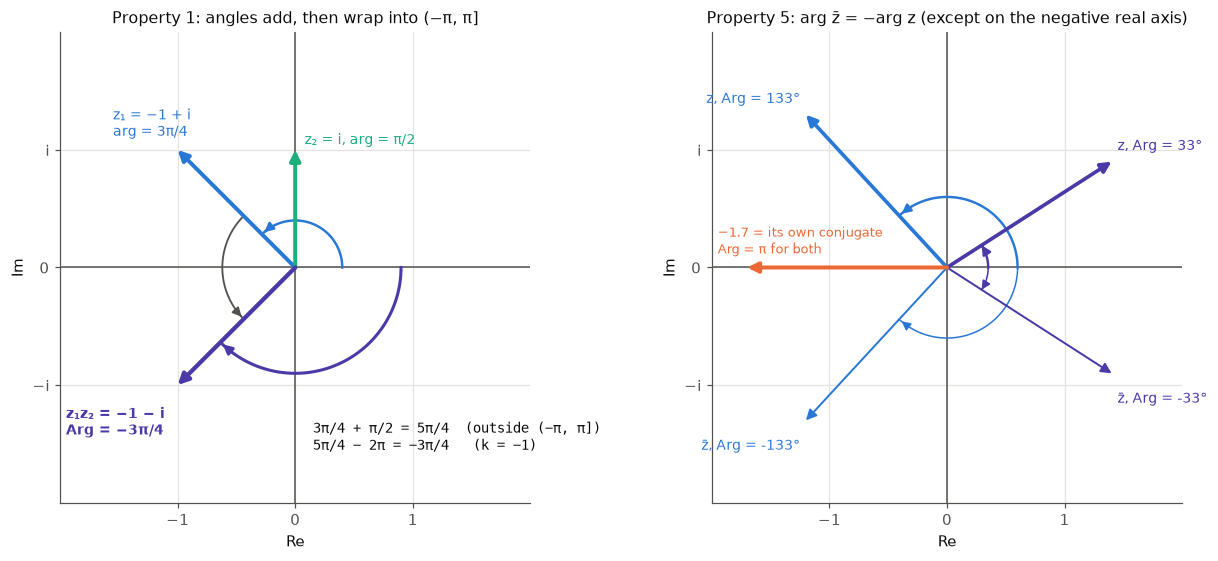

In [9]:
z1, z2 = -1 + 1j, 1j; p = z1*z2
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
ax = axes[0]; argand(ax, lim=2)
arrow(ax, 0, z1, BLUE, 2.6); arrow(ax, 0, z2, AQUA, 2.6); arrow(ax, 0, p, VIOLET, 2.8)
angle_arc(ax, np.angle(z1), r=0.4, color=BLUE, lw=1.6)
angle_arc(ax, np.angle(z1) + np.angle(z2), r=0.62, color=INK2, lw=1.2, start=np.angle(z1))
angle_arc(ax, np.angle(p), r=0.9, color=VIOLET, lw=2)
ax.text(z1.real - 0.55, z1.imag + 0.12, "z₁ = −1 + i\narg = 3π/4", color=BLUE, fontsize=9)
ax.text(z2.real + 0.08, z2.imag + 0.05, "z₂ = i, arg = π/2", color=AQUA, fontsize=9)
ax.text(p.real - 0.95, p.imag - 0.42, "z₁z₂ = −1 − i\nArg = −3π/4", color=VIOLET, fontsize=9, weight="bold")
ax.text(0.15, -1.55, "3π/4 + π/2 = 5π/4  (outside (−π, π])\n5π/4 − 2π = −3π/4   (k = −1)", fontsize=9, family="monospace")
ax.set_title("Property 1: angles add, then wrap into (−π, π]", fontsize=10.5)

ax = axes[1]; argand(ax, lim=2)
for z, c in [(1.4 + 0.9j, VIOLET), (-1.2 + 1.3j, BLUE)]:
    arrow(ax, 0, z, c, 2.4); arrow(ax, 0, np.conj(z), c, 1.3)
    angle_arc(ax, np.angle(z), r=0.35 + 0.25*(c == BLUE), color=c, lw=1.6); angle_arc(ax, -np.angle(z), r=0.35 + 0.25*(c == BLUE), color=c, lw=1)
    ax.text(z.real + 0.05*np.sign(z.real), z.imag + 0.1, f"z, Arg = {np.degrees(np.angle(z)):.0f}°", color=c, fontsize=9, ha="left" if z.real > 0 else "right")
    ax.text(z.real + 0.05*np.sign(z.real), -z.imag - 0.25, f"z̄, Arg = {-np.degrees(np.angle(z)):.0f}°", color=c, fontsize=9, ha="left" if z.real > 0 else "right")
arrow(ax, 0, -1.7, ORANGE, 2.6); ax.text(-1.95, 0.12, "−1.7 = its own conjugate\nArg = π for both", color=ORANGE, fontsize=8.5)
ax.set_title("Property 5: arg z̄ = −arg z (except on the negative real axis)", fontsize=10.5)
plt.tight_layout(); plt.show()

### Animation *(extra)*: $\arg(z^n) = n\arg z$, with wrapping
Take $z = 1.08\,e^{i\,\pi/5}$, so $\arg z = \frac{\pi}{5} = 36^\circ$. Each extra power adds another $\frac{\pi}{5}$. The table on the right compares $n\arg z$ with the principal $\operatorname{Arg}(z^n)$. They agree until $n\arg z$ passes $\pi$ (at $n = 6$), after which $\operatorname{Arg}(z^n) = n\arg z - 2\pi$. That's the $2k\pi$ correction in property 4.

In [10]:
z = 1.08*np.exp(1j*np.pi/5); Nmax = 12
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.2]))
ax = axes[0]; argand(ax, lim=2.6)
th = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(th), np.sin(th), color=GRID, lw=1)
P = z**np.arange(0, Nmax + 1)
trail, = ax.plot([], [], "o-", color=INK2, ms=3, lw=0.8, alpha=0.6)
vec, = ax.plot([], [], color=VIOLET, lw=2.6); arc, = ax.plot([], [], color=ORANGE, lw=2)
title = ax.set_title("", fontsize=10.5)
ax2 = axes[1]
n_all = np.arange(1, Nmax + 1); naive = n_all*np.pi/5; princ = np.angle(P[1:])
ax2.axhspan(-np.pi, np.pi, color=VIOLET, alpha=0.05); ax2.axhline(np.pi, color=INK2, ls="--", lw=0.8); ax2.axhline(-np.pi, color=INK2, ls="--", lw=0.8)
s1, = ax2.plot([], [], "s", color=BLUE, ms=8, alpha=0.5, label="n · arg z")
s2, = ax2.plot([], [], "o", color=VIOLET, ms=7, label="principal Arg(zⁿ)")
ax2.set_xlim(0.5, Nmax + 0.5); ax2.set_ylim(-3.6, 8); ax2.set_xticks(n_all); ax2.set_xlabel("n")
ax2.set_yticks(np.arange(-1, 3)*np.pi, ["−π", "0", "π", "2π"]); ax2.legend(frameon=False, fontsize=9, loc="upper left")
note = ax2.text(1, -3.3, "", fontsize=9.5, family="monospace")
ax2.set_title("they differ by 2π once n · arg z > π", fontsize=10.5)
def update(f):
    n = f + 1; w = P[n]
    trail.set_data(P[:n + 1].real, P[:n + 1].imag); vec.set_data([0, w.real], [0, w.imag])
    t = np.linspace(0, np.angle(w), 50); arc.set_data(0.5*np.cos(t), 0.5*np.sin(t))
    title.set_text(f"z^{n}:  Arg = {pi_str(np.angle(w))}")
    s1.set_data(n_all[:n], naive[:n]); s2.set_data(n_all[:n], princ[:n])
    k = int(round((princ[n - 1] - naive[n - 1])/(2*np.pi)))
    note.set_text(f"n={n:>2}: {pi_str(naive[n-1]):>6} + 2({k:+d})π = {pi_str(princ[n-1])}")
    return trail, vec, arc, title, s1, s2, note
anim = animation.FuncAnimation(fig, update, frames=Nmax, interval=700, blit=False)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## Summary

| Idea | Result |
|---|---|
| Definition | $\arg z$ = angle of $Oz$ from the **positive real axis**. Anticlockwise is $+$, clockwise is $-$, in radians |
| Principal (amplitude) | $-\pi < \operatorname{Arg} z \le \pi$, and "argument" alone means this |
| General | $\operatorname{Arg} z + 2k\pi$ |
| Method | **plot first**, find acute $\alpha$ from $\tan\alpha = \lvert b/a\rvert$, then I: $\alpha$, II: $\pi - \alpha$, III: $-(\pi - \alpha)$, IV: $-\alpha$ |
| Sign | upper half (I, II) positive, lower half (III, IV) negative |
| Axes | $+$real: $0$, $-$real: $\pi$, $+$imag: $\frac{\pi}{2}$, $-$imag: $-\frac{\pi}{2}$ |
| Zero | $\arg 0$ is **not defined** |
| Properties | $\arg(z_1z_2) = \arg z_1 + \arg z_2$, $\;\arg(z_1/z_2) = \arg z_1 - \arg z_2$, $\;\arg z^n = n\arg z$, each $+\,2k\pi$ to stay in range |
| Conjugate | $\arg\bar z = -\arg z$, except on the negative real axis |

---
## Homework from the lecture
Find the **principal** argument of each. Use the **properties** rather than multiplying out, then check by multiplying.
1. $z_1 = (1 + i)(\sqrt3 + i)$
2. $z_2 = (1 - i)^3$

<details>
<summary>Answers (open after attempting)</summary>

1. $\arg(1 + i) = \frac{\pi}{4}$ and $\arg(\sqrt3 + i) = \frac{\pi}{6}$. By property 1: $\arg z_1 = \frac{\pi}{4} + \frac{\pi}{6} = \frac{5\pi}{12}$, already in range, so $k = 0$.
   Check: $z_1 = (\sqrt3 - 1) + i(\sqrt3 + 1)$, in quadrant I. ✓
2. $\arg(1 - i) = -\frac{\pi}{4}$. By property 4: $\arg z_2 = 3\cdot\left(-\frac{\pi}{4}\right) = -\frac{3\pi}{4}$, in range, so $k = 0$.
   Check: $(1 - i)^3 = (1 - i)^2(1 - i) = (-2i)(1 - i) = -2 - 2i$, in quadrant III. ✓
</details>

## Practice *(extra)*
3. Find $\operatorname{Arg}$ of $-2 + 2i$, $\;-3$, $\;-\sqrt3 + i$, $\;-4i$, $\;\frac{1 + i}{1 - i}$.
4. Find $\operatorname{Arg}\big[(-1 + i)^5\big]$. *(Watch the wrap-around.)*
5. If $\arg z = \frac{\pi}{3}$, what is $\arg\bar z$? What is $\arg(-z)$?

<details>
<summary>Answers</summary>

3. $\frac{3\pi}{4}$, $\;\pi$, $\;\frac{5\pi}{6}$, $\;-\frac{\pi}{2}$, $\;\frac{\pi}{4} - \left(-\frac{\pi}{4}\right) = \frac{\pi}{2}$ (indeed $\frac{1 + i}{1 - i} = i$).
4. $5\cdot\frac{3\pi}{4} = \frac{15\pi}{4}$. Subtract $2\cdot2\pi$: $\frac{15\pi}{4} - 4\pi = -\frac{\pi}{4}$. Check: $(-1 + i)^5 = -4(-1 + i) = 4 - 4i$. ✓
5. $\arg\bar z = -\frac{\pi}{3}$. $-z$ is $z$ turned by $\pi$: $\frac{\pi}{3} + \pi = \frac{4\pi}{3}$, then $-2\pi$ gives $-\frac{2\pi}{3}$.
</details>

In [11]:
# Checks for the homework and practice
z1 = (1 + 1j)*(np.sqrt(3) + 1j); z2 = (1 - 1j)**3
print("HW1: z1 =", np.round(z1, 4), "  Arg =", pi_str(np.angle(z1)), "  via property: π/4 + π/6 =", pi_str(np.pi/4 + np.pi/6))
print("HW2: z2 =", np.round(z2, 4), "  Arg =", pi_str(np.angle(z2)), "  via property: 3·(−π/4) =", pi_str(-3*np.pi/4))
print("P3 :", [pi_str(np.angle(complex(w))) for w in [-2 + 2j, -3 + 0j, -np.sqrt(3) + 1j, -4j, (1 + 1j)/(1 - 1j)]])
print("P4 :", np.round((-1 + 1j)**5, 6), " Arg =", pi_str(np.angle((-1 + 1j)**5)))
z = np.exp(1j*np.pi/3); print("P5 : Arg z̄ =", pi_str(np.angle(np.conj(z))), "  Arg(−z) =", pi_str(np.angle(-z)))

HW1: z1 = (0.7321+2.7321j)   Arg = 5π/12   via property: π/4 + π/6 = 5π/12
HW2: z2 = (-2-2j)   Arg = −3π/4   via property: 3·(−π/4) = −3π/4
P3 : ['3π/4', 'π', '5π/6', '−π/2', 'π/2']
P4 : (4-4j)  Arg = −π/4
P5 : Arg z̄ = −π/3   Arg(−z) = −2π/3
